---
title: "Conda、CUDA、cuDNN、Python 与 PyTorch 环境配置完整指南"
description: "从 Conda 安装开始，完整介绍 CUDA、cuDNN、Python、PyTorch 的安装与版本匹配，并附 CUDA 与 NVIDIA 显卡及 PyTorch 版本对照说明。"
date: 2026-08-30
categories:
  - Deep Learning
  - Environment Setup

format:
  html:
    toc: true
    toc-depth: 3
    code-fold: true
    code-tools: true
---

> 此部分是结合各个攻略总和而来的教程，帮助新手快速上手安装。

## Conda 安装与使用

### 什么是 Conda？

Anaconda 是专门为了方便使用 Python 进行数据科学研究而建立的一组 软件包，涵盖了数据科学领域常见的 Python 库，并且自带了专门用来解决软件环境依赖问题的 conda 包管理系统。主要是提供了包管理与环境管理的功能，可以很方便地解决多版本python并存、切换以及各种第三方包安装问题。Anaconda利用工具/命令conda来进行package和environment的管理，并且已经包含了Python和相关的配套工具。

conda可以理解为一个工具，也是一个可执行命令，其核心功能是包管理与环境管理。包管理与pip的使用类似，环境管理则允许用户方便地安装不同版本的python并可以快速切换。

Anaconda则是一个打包的集合，里面预装好了conda、某个版本的python、众多packages 、科学计算工具等等，所以也称为Python的一种发行版。其实还有Miniconda，它只包含最基本的内容——python与conda，以及相关的必须依赖项，对于空间要求严格的用户，Miniconda是一种选择。

conda将几乎所有的工具、第三方包都当做package对待，甚至包括python和conda自身！因此，conda打破了包管理与环境管理的约束，能非常方便地安装各种版本python、各种package并方便地切换。

### 下载

我们可以前往<a href="https://www.anaconda.com/download" target="_blank">Anconda官方</a>下载。

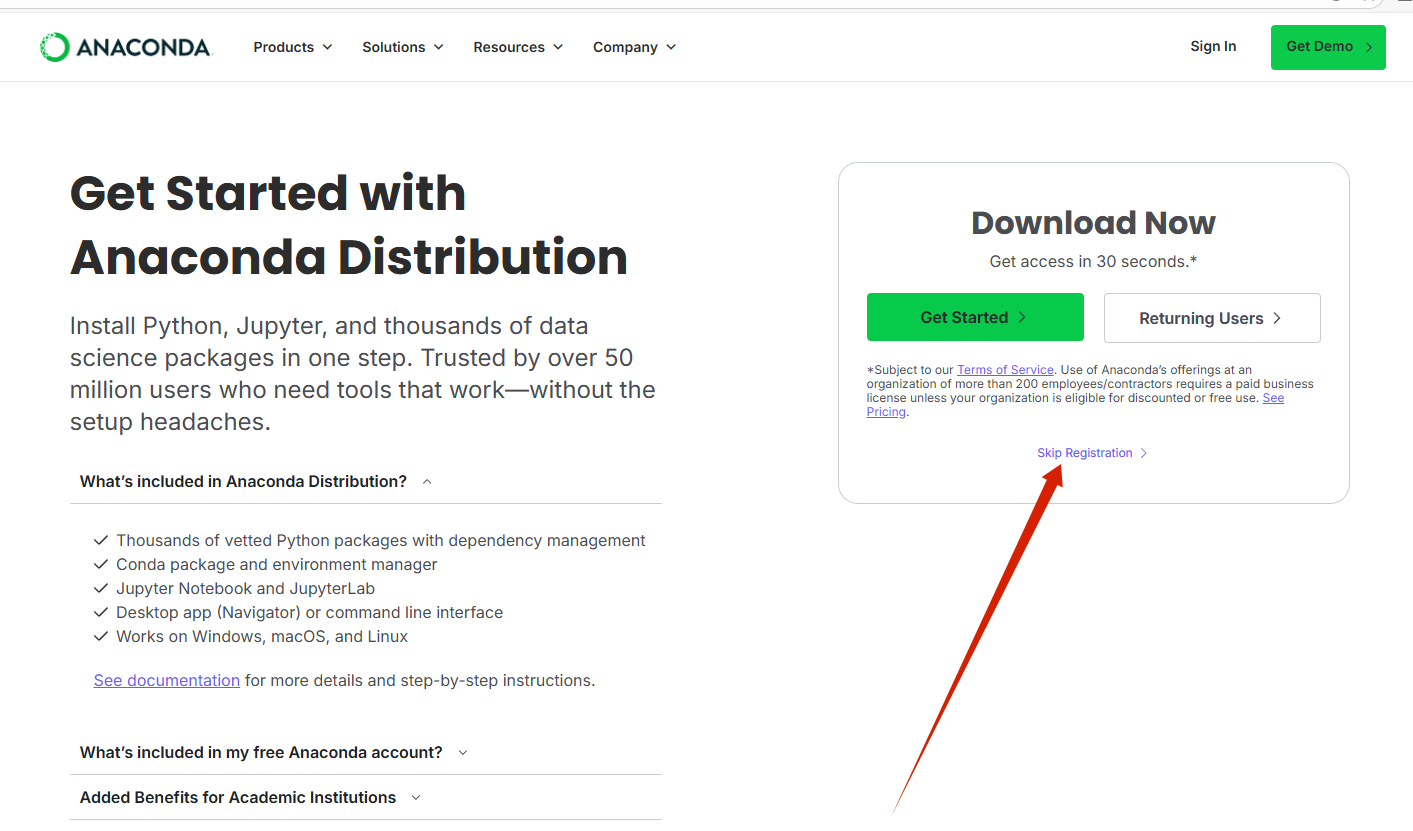

可以跳过注册，我们直接进入下载界面。

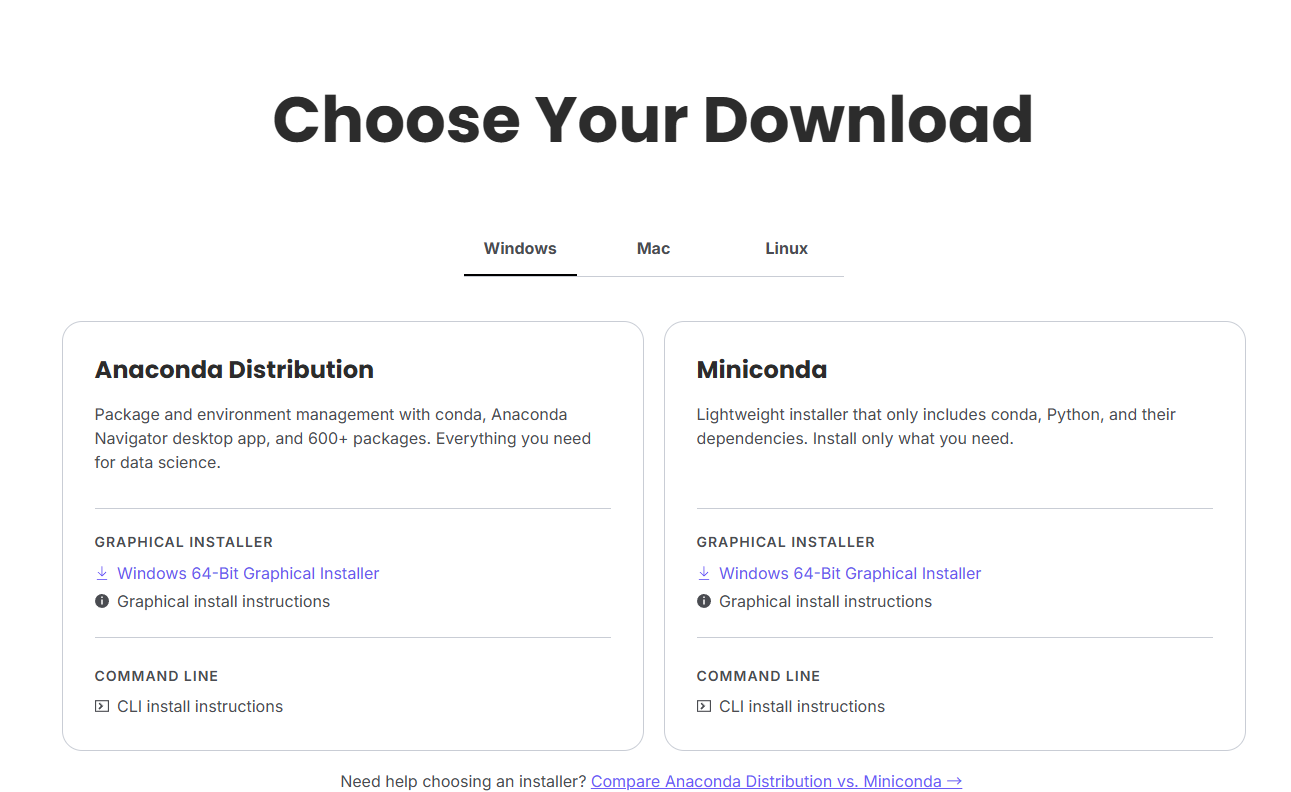

可以看到，此处我们可以下载Anconda或者Miniconda，请你按照自己的需求下载。

运行安装包执行文件，依次点击下一步即可，可以自定义安装的路径，中间的安装设置按照默认的来即可。

如果你有任何问题，可以前往<a href="https://www.anaconda.com/docs/getting-started/installation" target="_blank">Anconda安装指南</a>，选择你的对应选项，既可以获得详细的安装教程。例如下图这样。

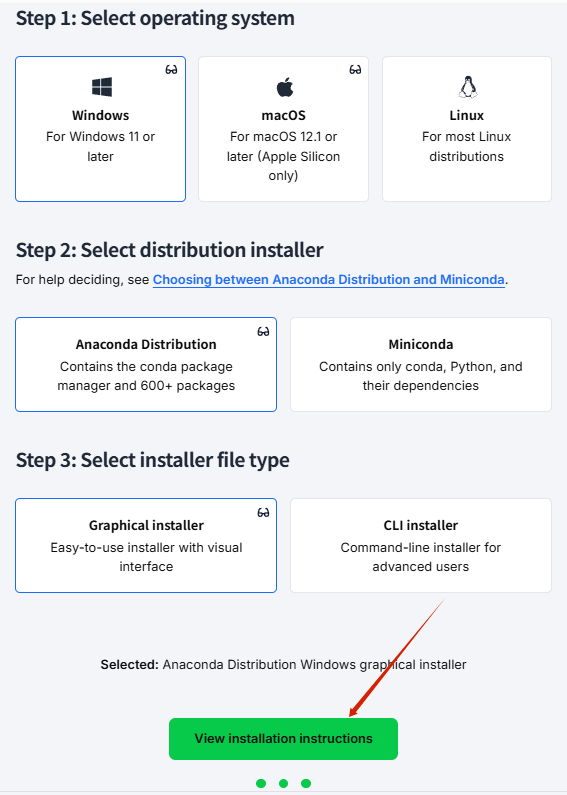

我们点击箭头处按钮就可以获得对应的安装指南。

完场上述步骤之后，需要再检查下 `conda` 是否能够正常使用。在电脑左下角搜索找到 `Anaconda Prompt`，点击打开后，在控制台中输入 `conda --version`，回车如果返回了 `conda` 版本信息则说明安装成功。

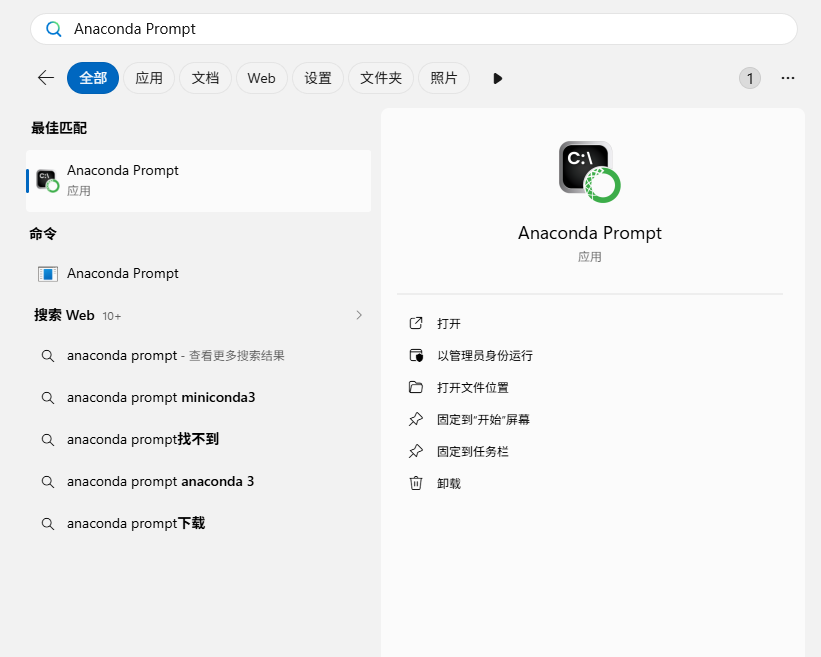

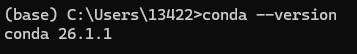

如图，就代表我们安装成功了。

在窗口中输入 `conda list`，会返回**当前环境**下已经安装好的包，如果出现该列表则说明 conda 已经正确安装。其中，包含了对应的解释器 python。

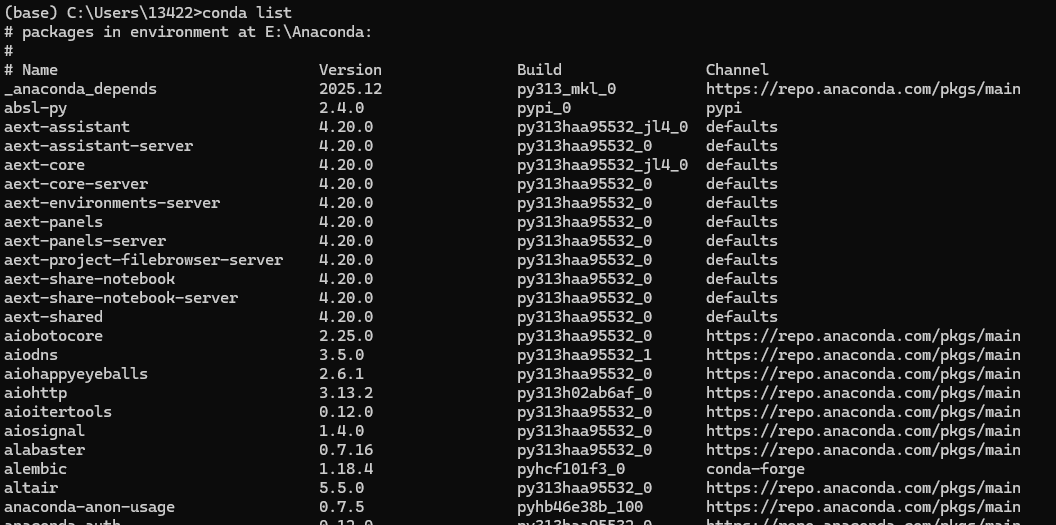

一般来说，我们是不会处理我们的`base`环境的。接下来我们会介绍一些Conda的常见操作。学会这些就已经差不多。

### 使用

至此完成了 conda 包和环境管理工具的安装，此时我们可以进行一些简单的配置并尝试创建 conda 环境，安装需要的库和运行简单的 python 程序。

#### 配置下载源

Conda 包管理器下载各类库的来源是国外的服务器，常常会面临下载速度慢的问题。可以为 conda 添加 软件包通道 （channel），以清华源为例，在打开的 `Anaconda prompt` 控制台窗口中，输入如下命令可以将清华源的两个地址添加到通道。

```bash
conda config --add channels https://mirrors.tuna.tsinghua.edu.cn/anaconda/pkgs/free/
conda config --add channels https://mirrors.tuna.tsinghua.edu.cn/anaconda/pkgs/main/
```

为了在查看 conda 软件包通道的下载链接时能显示我们手动配置的通道地址，可以通过如下命令进行设置：
```bash
conda config --set show_channel_urls yes
```

如果不配置下载源，conda 会使用默认的软件包通道，即从官方 Anaconda 仓库获取软件包。具体的软件包通道情况可以通过 `conda config --show` 命令查看，返回的信息不仅能看到下载源的地址信息，还能看到创建的 conda 环境所在的文件夹。如果想要重置下载源的信息，可以用 `conda config --remove-key channels` 命令实现。

此部分仅仅介绍到此即可，只要只要学会，可以使用国内的地址来下载各类库即可，如果有别的想添加的通道，可以询问AI，并让他提供conda的指令即可。

#### 环境管理

现在来到 conda 的另一大功能，就是环境管理，它可以创建、管理和切换不同的环境，这些环境之间是相互独立的，每个环境当中的 Python 版本和软件包版本可以不相同，使得我们可以把依赖版本不同的项目放在同一台设备上的不同 conda 环境中运行。

##### 创建（删除）环境

要创建一个新的 conda 环境，可以使用 `conda create` 命令，指定该环境下所需的 Python 版本和要安装的软件包。例如：

```bash
conda create -n myenv python=3.8 numpy==1.24.0 matplotlib
```

其中`myenv`是我们的环境名，可以随意取，但是最好是针对你环境工作情况来取，这样你可以更简单的管理你的环境。

并在其中安装 `Python 3.8`、`NumPy 1.24.0` 和 `Matplotlib`。在创建环境时，会有软件包列表的提示。输入 y 确认后即等待环境创建即可。此处注意版本，如果你没有像`numpy`一样写好版本，他就会像`matplotlib`一样直接安装最新版。

如果不想要一个环境了，例如我们要把 myenv 这个名字的环境删除，可以通过如下命令进行删除：

``` bash
conda remove -n myenv --all
```

此时我们就可以使用`conda env list`来查看我们现在有几个环境，如图：

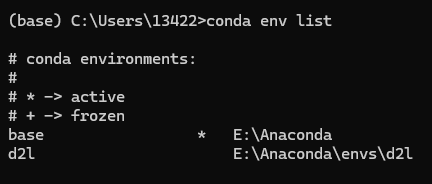

##### 激活（切换）环境

但是此时我们根据如下位置判断我们所在的 conda 环境仍然是名为 base 的环境，因此我们要激活并切换到 myenv 环境中。

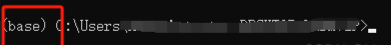

通过如下命令可实现激活并切换环境的功能，不同系统上的命令有所区别。

```bash
# windows
conda activate myenv
# Linux/Unix
source activate myenv
```

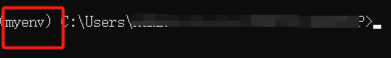

如果不切换环境，而只是退出当前环境，可以用 `conda deactivate` 退出当前的 conda 环境。

##### 下载（卸载）库

当我们要在不同环境下安装库时，需要先切换到指定环境当中，例如我们要下载或者卸载 `scipy`，可以执行如下命令进行：

```bash
# 下载安装
conda install scipy
# 卸载
conda remove scipy
```

至于版本选择，与我们前面的环境创建的规则是一致的。

##### 导出（导入）环境

当我们想要保存某个环境的配置信息，例如下载源信息、环境的Python版本信息、安装的包的版本信息等，可以先切换到指定环境下，通过以下命令将这些配置信息导出：

```bash
conda env export > environment.yml
```
该命令会将当前的环境配置信息导出到为 `environment.yml` 配置信息文件，文件导出地址默认为当前工作目录（也可以指定输出的绝对地址）。

这时候，我们将配置文件传到另一台电脑，想基于该配置文件创建 conda 环境，可以通过以下命令：

```bash
conda env create -f environment.yml
```


#### 试运行 py 文件

这里我们写一个名为 `test.py` 的简单的 python 脚本，但用到需要额外安装的 `numpy` 库，代码如下：

```python
import numpy as np

array = np.random.rand(10)
mean = np.mean(array)
print(mean)
```

将该脚本文件放到控制台的工作目录下（或者把控制台工作目录切换到脚本文件的位置），输入如下命令：

```bash
python test.py
```

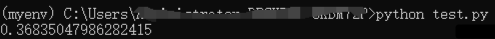

### 在VSCode或者Pycharm中使用Conda环境

此部分比较基础，可以前往这个<a href="https://www.cnblogs.com/haima/p/17441000.html" target="_blank">链接</a>的第六第七部分学习。

如果还是不懂的话可以自己多试试:)，我就不写了，实在不是因为不想再下一次Pycharm

## CUDA与cuDNN 安装与验证

如果你已经开始准备进行深度学习，使用GPU加速是必要的，所以我们会用到`CUDA`，此处会有详细的使用方法，但是**请你先别急着跟着下载**，先看完以后，在与下一部分的版本对照下载:)

### 准备工作与环境检查

在安装前，需要先确保你的电脑硬件和软件环境满足要求。

你需要一块来自NVIDIA的独立 显卡。可以访问<a href="https://developer.nvidia.com/cuda/gpus" target="_blank">NVIDIA官网的CUDA GPU列表</a>查询你的显卡型号是否支持CUDA。

接下来，我们可以按下`Win+R`打开我们的运行界面，再输入`cmd`，打开命令提示符。输入 `nvidia-smi` 并回车。

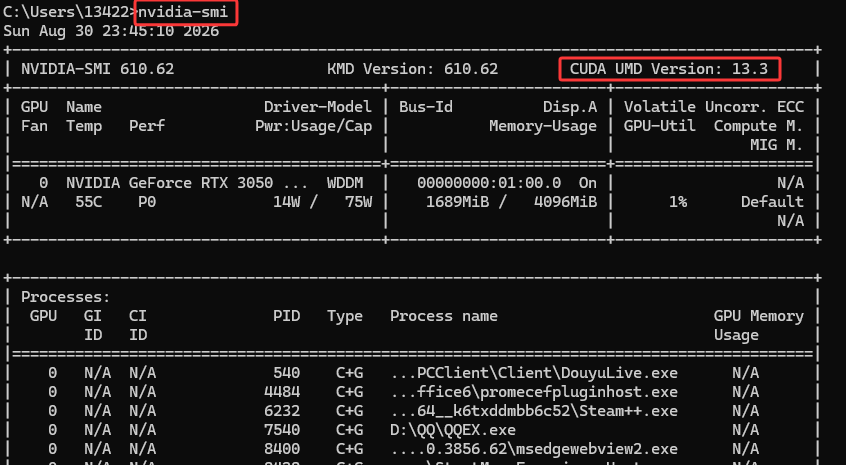

“CUDA Version” 字段则代表当前驱动最高能支持的CUDA版本，不是你已安装的CUDA，我们这边就说明我们最高可以安装`CUDA 13.3`的版本。如果不够的话，就更新自己的英伟达驱动即可。

如果你还没有下载NVIDIA驱动，请你前往<a href="https://www.nvidia.cn/geforce/drivers/" target="_blank">驱动下载页面下载并安装最新的显卡驱动。</a>NVIDIA

### 安装CUDA Toolkit

CUDA 是NVIDIA推出的并行计算平台和编程模型 ，是GPU加速的基础。

我们可以前往<a href="https://developer.nvidia.com/cuda-toolkit-archive" target="_blank">CUDA Toolkit下载页面</a>。

且等我们选择好我们的CUDA版本以后，安装对应的CUDA Toolkit即可。例如我们想安装13.0版本，我们就可以安装下图红框的版本，但是我们最好还是装其中的最新版。

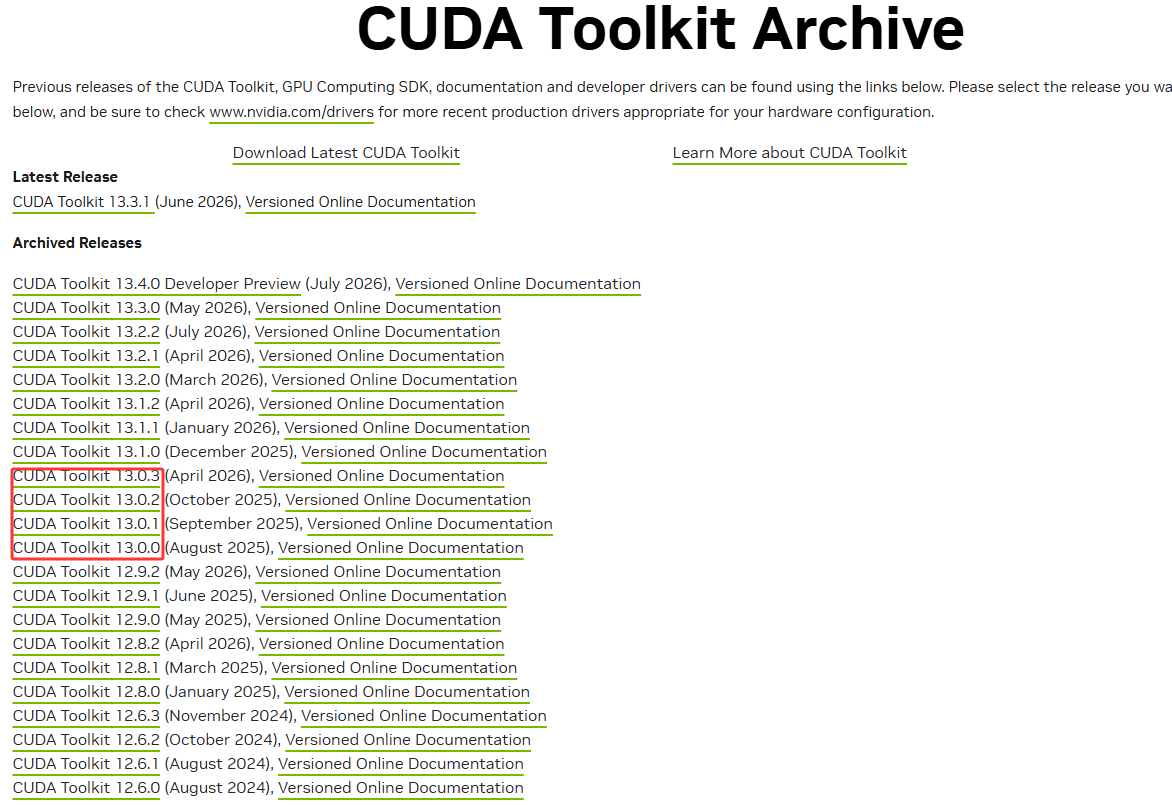

推荐下载local版本：

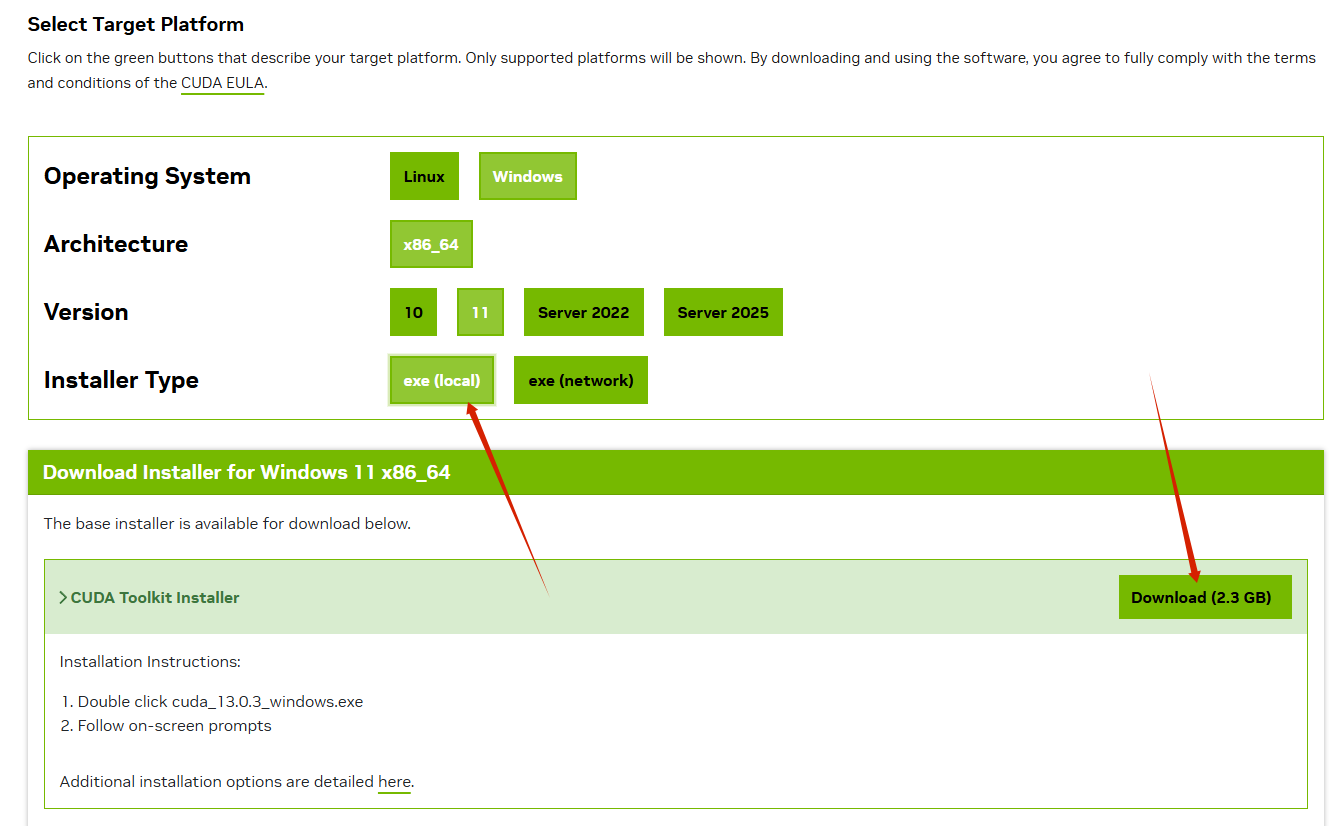

下面为安装过程。

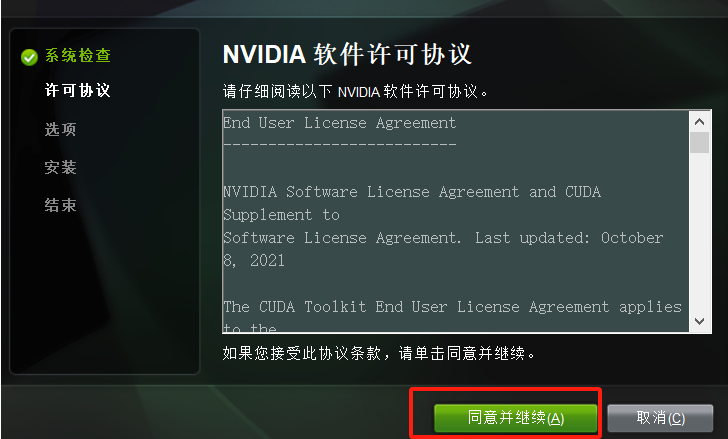

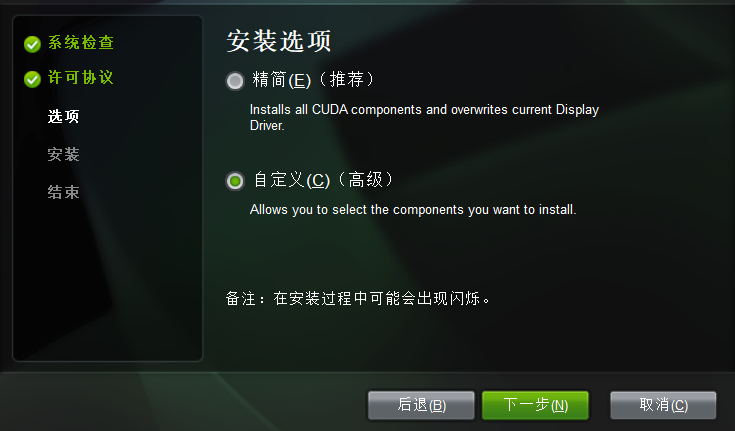

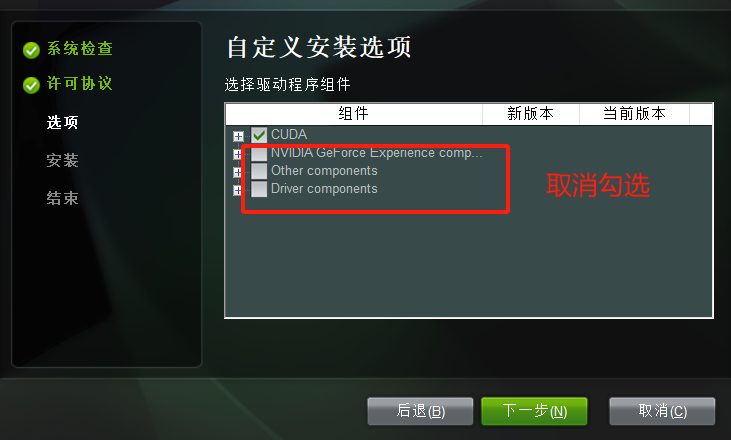

这其中的组件分别有以下作用：

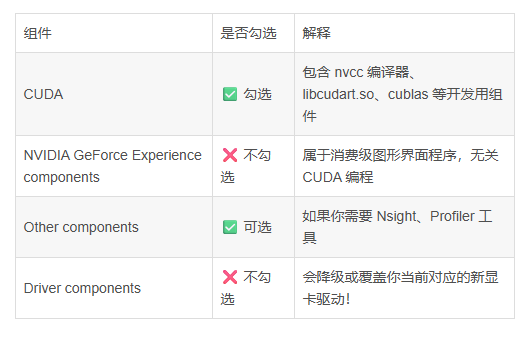

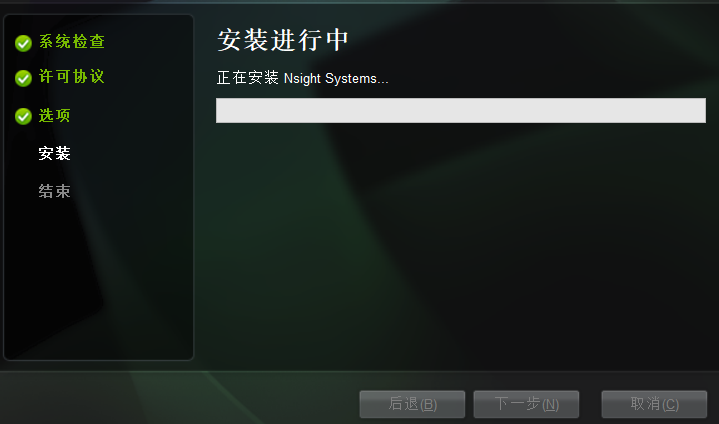

安装完成重启电脑。我们再进行下一步操作。

此处我们补充一个点,如果你安装的版本非常低,例如11.8等等,可能安装前,CUDA在安装过程中会有两个选择路径的时候。

第一次选择的时候,是刚刚开始安装的时候:(此处由于我没有下载低版本,我就使用CSDN中的图片了)

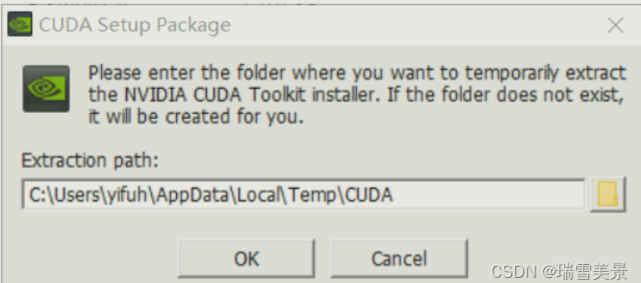

此时的地址为临时安装的地址,可以就默认,因为后期安装完成后,这个文件夹会被自动删除.

第二次是在选择组件以后的选择路径:

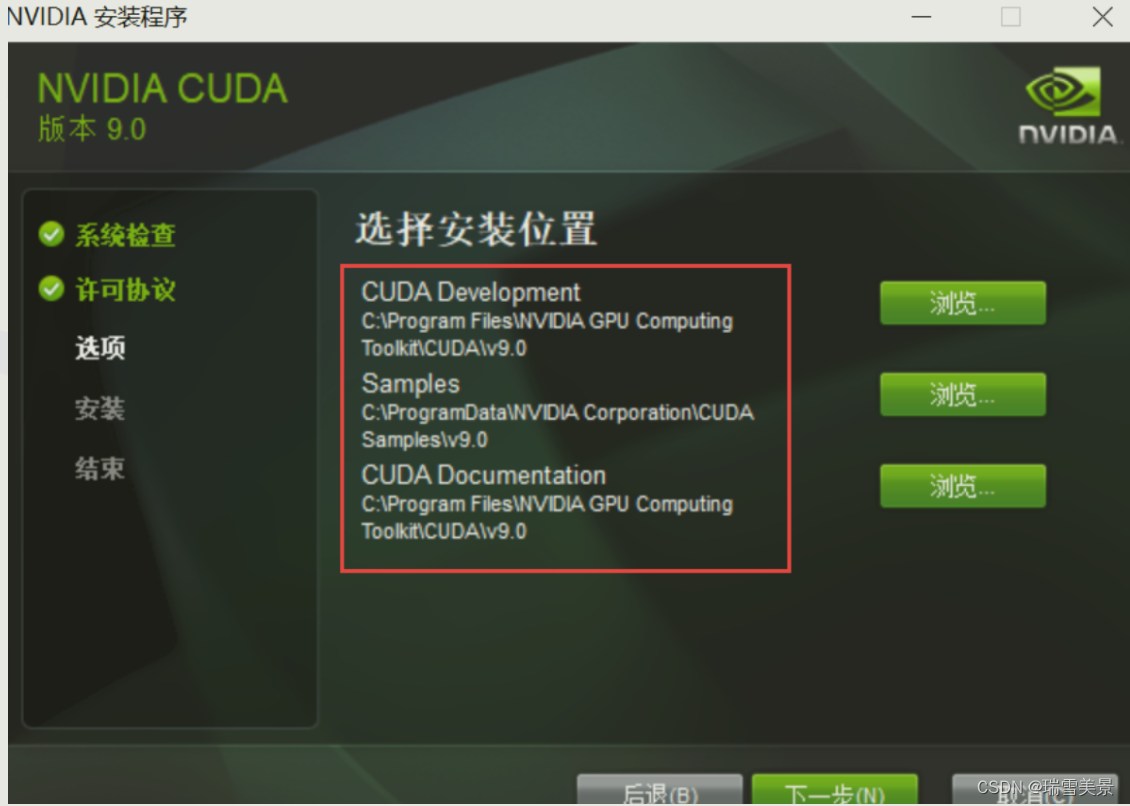

如图,这时候的路径是会保存下来的,可以自定义

一定要注意这两个图片中的路径不要设置成同一个路径，因为cuda安装完会自动删除一开始的临时安装文件，设置成一样的，cuda也会被同时删除

安装程序通常会自动添加系统环境变量。为保险起见，建议手动检查：

右键点击“此电脑” -> “属性” -> “高级系统设置” -> “环境变量”。

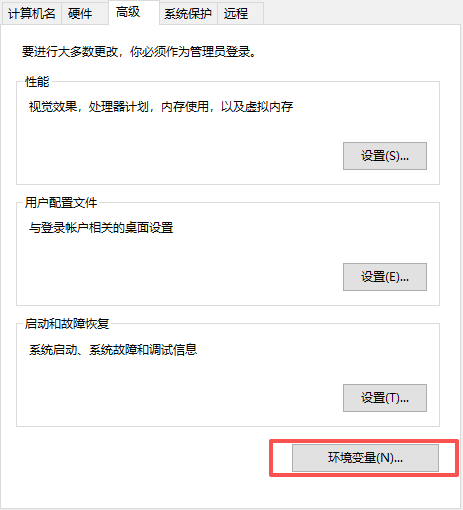

在“系统变量”中找到并选中Path，点击“编辑”。

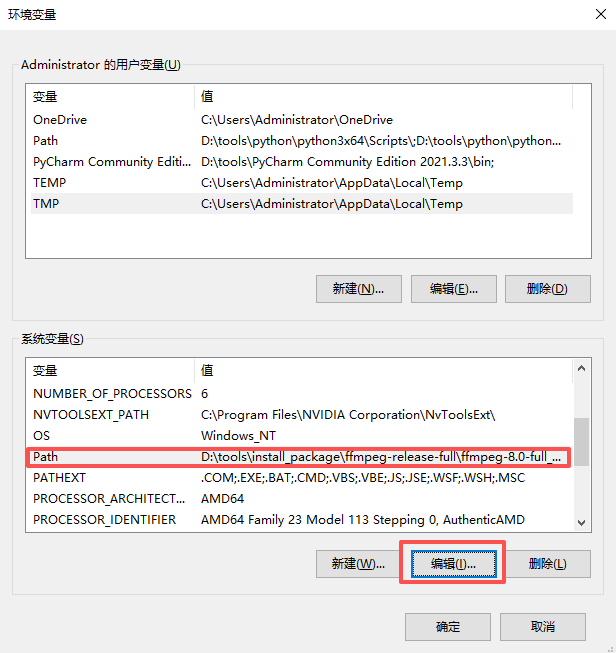

注意,如果以下路径已经有了就不要动了,我们这边只是保险起见:

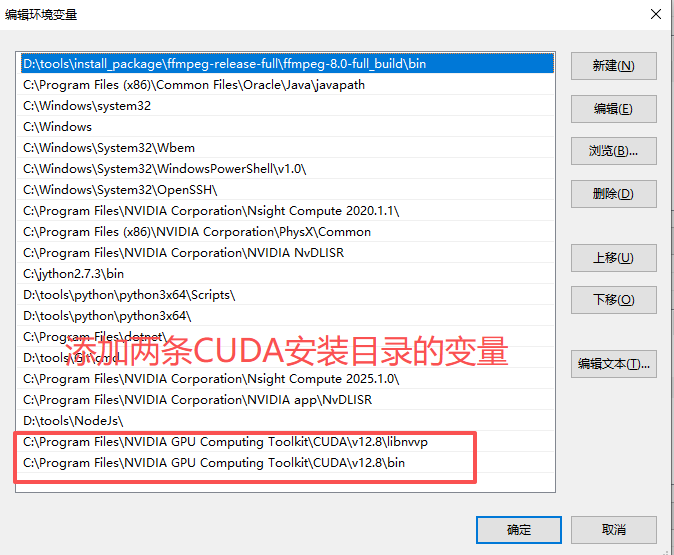

再先查看系统环境变量是否有添加以下2个环境变量，没有则手动添加，确保其中包含以下两条CUDA的路径:

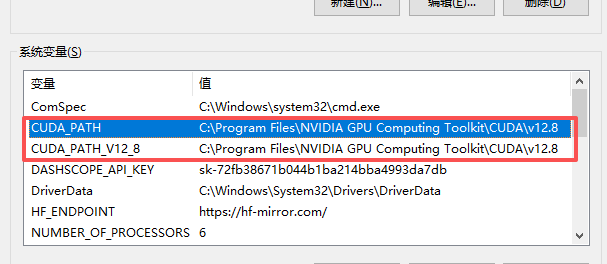

其中的V后面的是你的版本,如果你是13.0,就变成V13_0即可

如果没有，请点击“新建”手动添加。



### 安装cuDNN库

cuDNN是NVIDIA针对深度神经网络 优化的GPU加速库。**安装cuDNN前，必须确保CUDA已成功安装**。

我们可以前往<a href="https://developer.nvidia.com/rdp/cudnn-archive" target="_blank">cuDNN下载页面。</a>

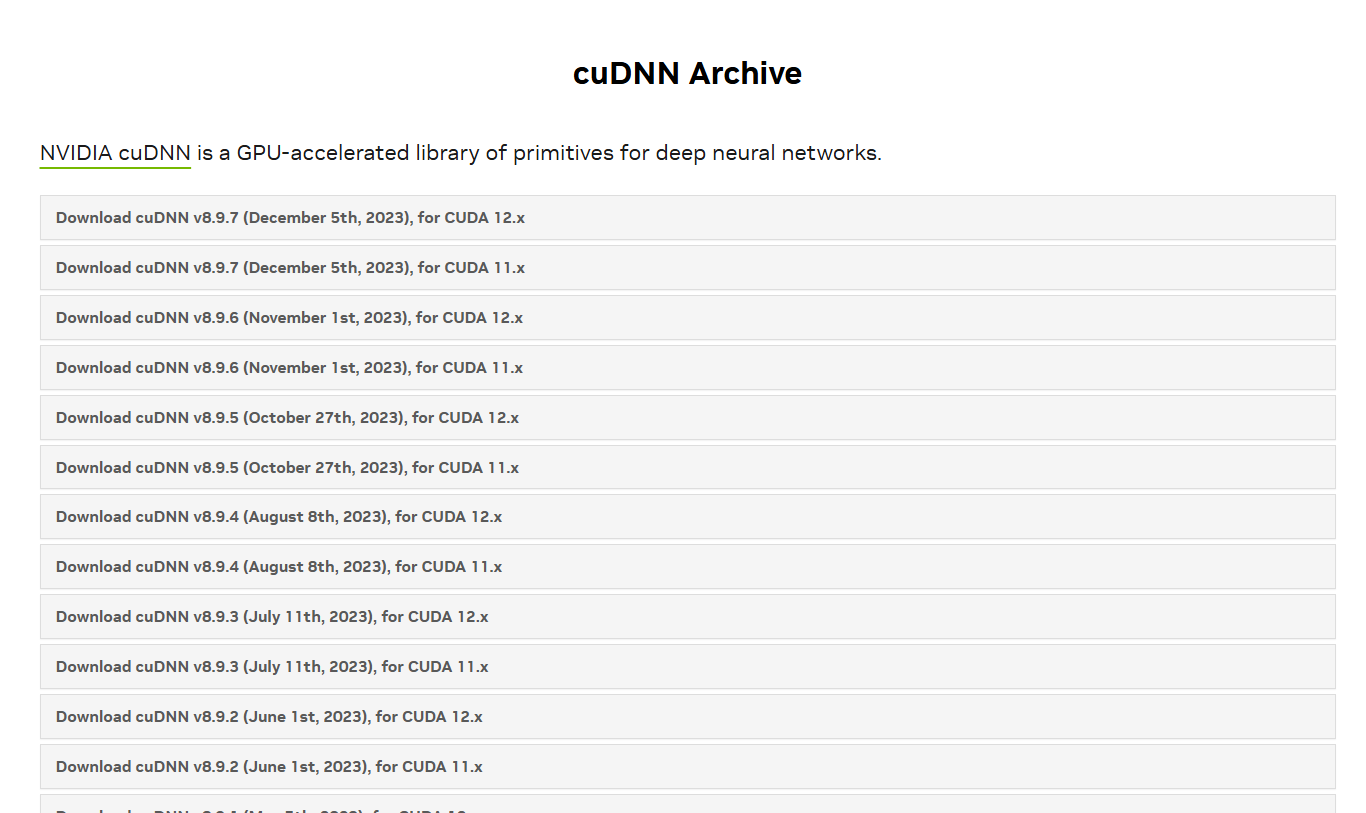

这是最重要的一步：你必须下载与你的CUDA版本严格匹配的cuDNN版本。例如，如果你安装了`CUDA 12.8`，就必须下载对应`CUDA 12.x`系列的cuDNN。

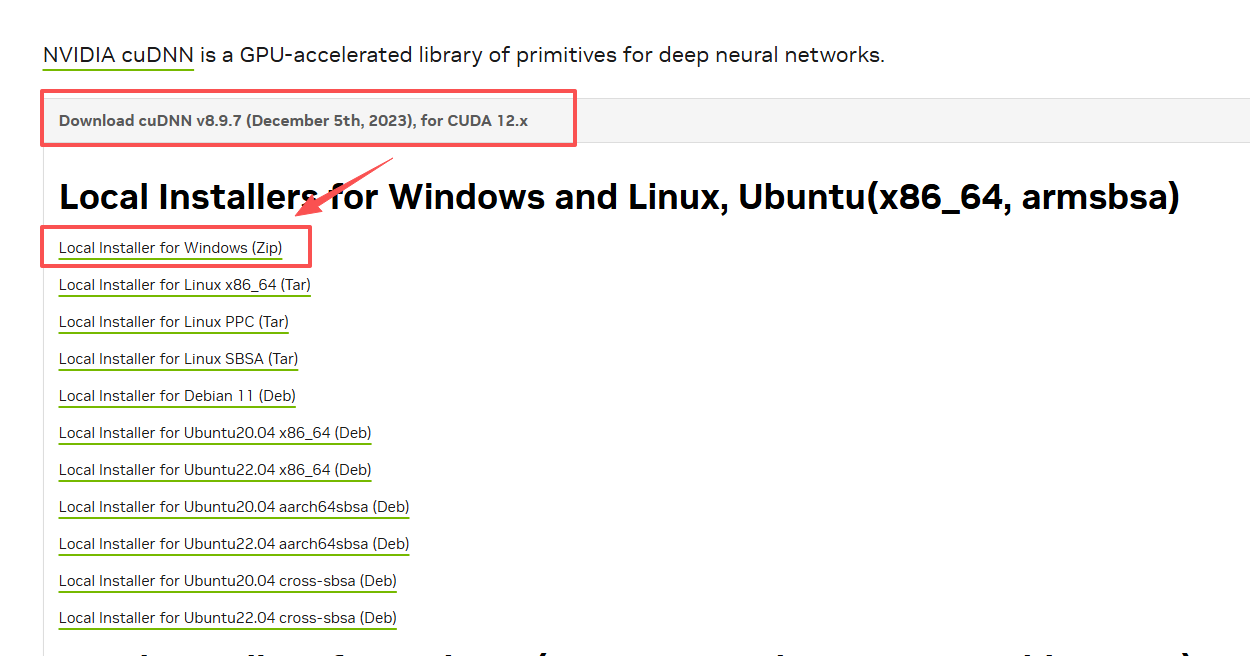

cuDNN的安装本质上就是将文件复制到CUDA的目录中。

下载的文件是一个压缩包（如.zip格式），将其解压，你会看到 bin、include、lib 三个文件夹。

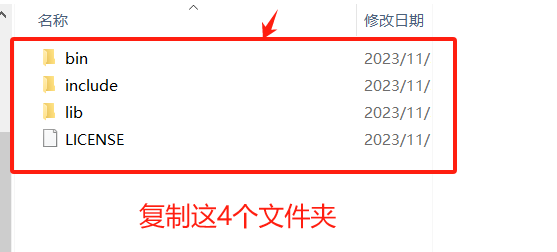

打开你的CUDA安装目录（第二步中记住的路径，例如 C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.8）。

将解压后 bin、include、lib 文件夹中的所有内容，分别复制（或拖放）到CUDA目录下对应的同名文件夹里。如果提示需要管理员权限或文件覆盖，选择同意即可。需要注意：**之后重启电脑**

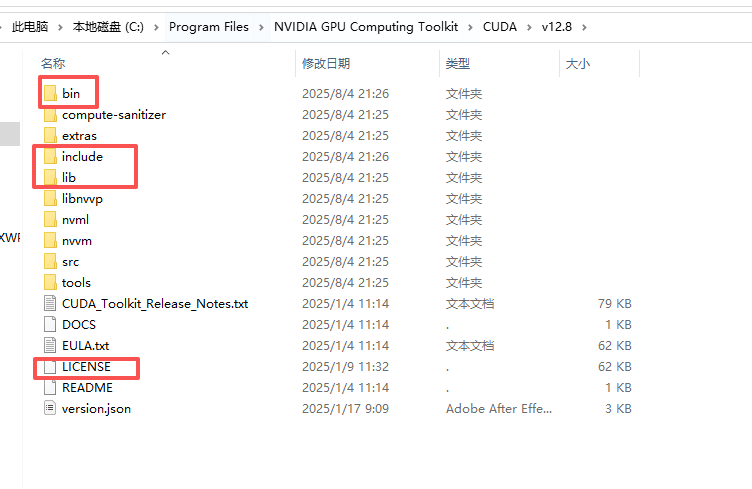

> 请注意：一个常见的错误是将cuDNN文件复制到了错误的子目录（如 compute-sanitizer），这会导致安装失败。请确保文件被复制到了CUDA根目录下的 bin、include、lib 文件夹。

### 验证安装

#### 验证CUDA
完成以上步骤后，请重启电脑，然后通过以下方法验证是否安装成功。

打开新的命令提示符，输入 nvcc --version 并回车。

如果成功安装，该命令将显示你安装的CUDA编译器（nvcc）的版本信息:

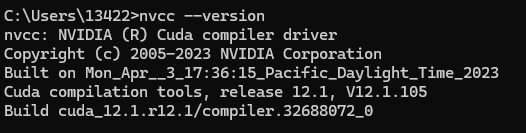

#### 验证cuDNN（通过Python/PyTorch）（不是开发的可以不用验证这一步）

这是验证整个环境（CUDA + cuDNN）是否可用的最佳方式。

打开命令提示符，运行以下命令：

```bash
python -c “import torch; print(torch.cuda.is_available())”
```

如果输出为 True，则恭喜你，你的PyTorch已经可以成功调用GPU进行加速了,但是注意要先安装Pytorch,不然的话肯定用不了。

## Pytorch

我们前往<a href="https://pytorch.org/" target="_blank">Pytorch官网</a>

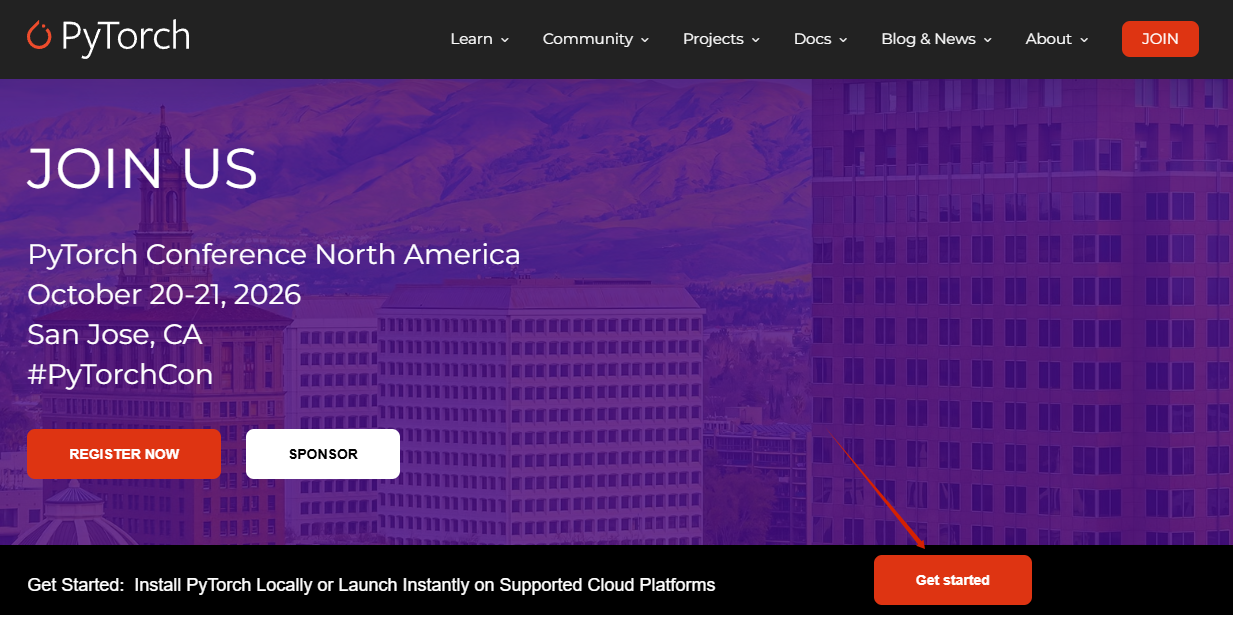

选择我们想要的版本,复制下方的指令到我们想要安装Pytorch的Conda环境,就可以成功安装了

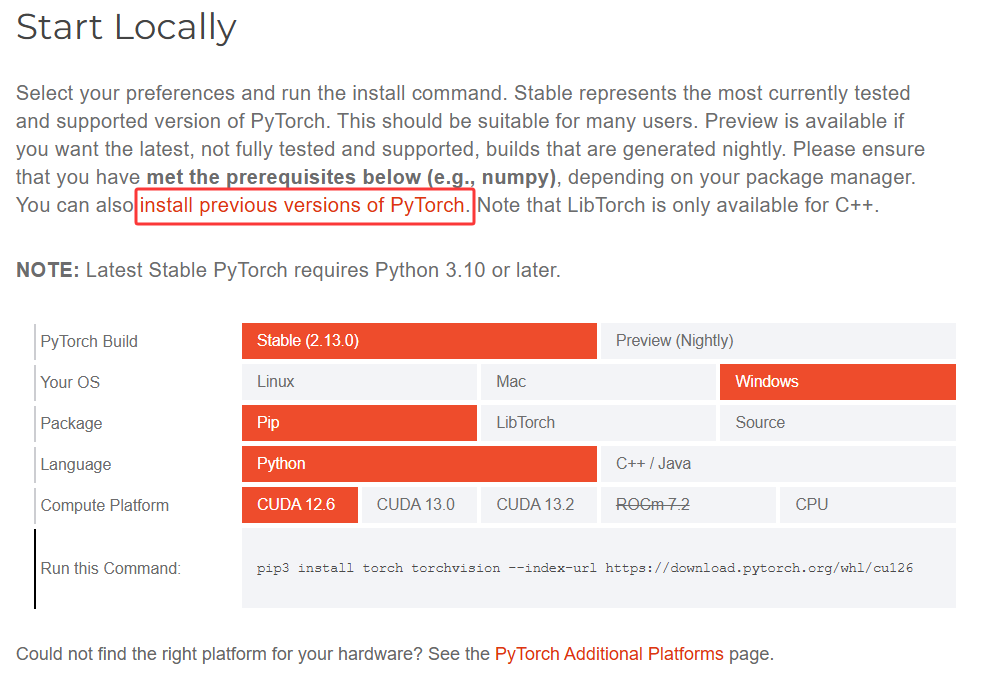

如果你的CUDA版本不在这个表格里,可以前往红框处下载历史版本.

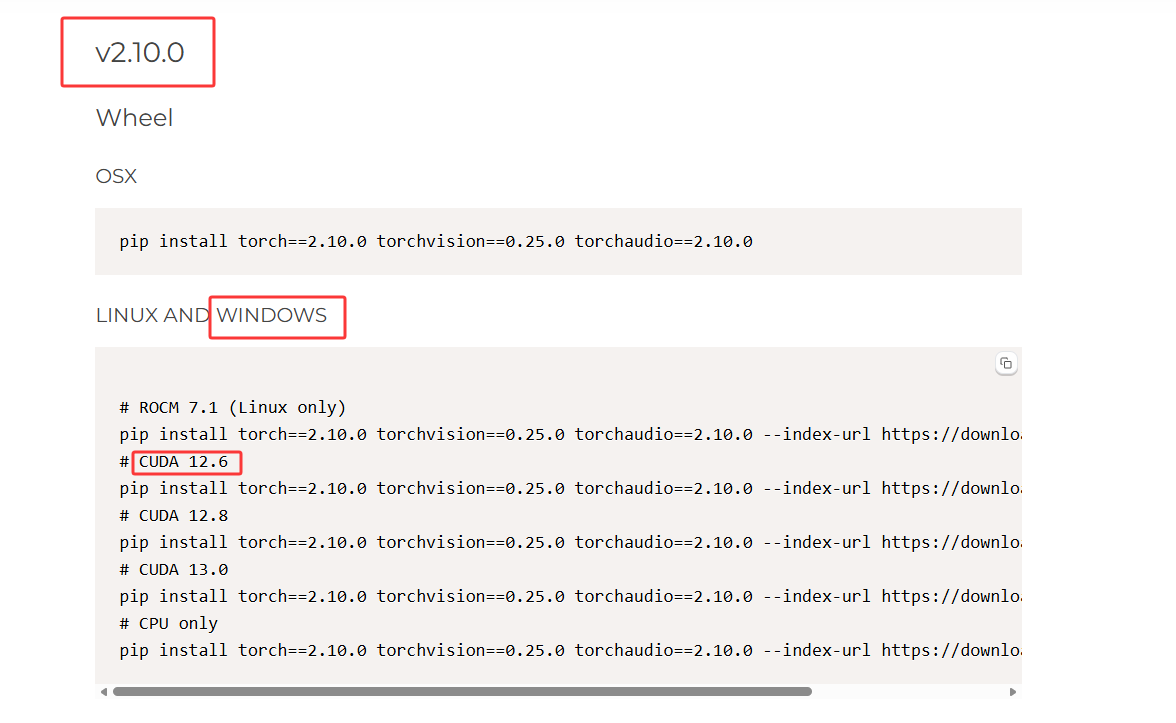

如图我们就展示了,如果我们要下载`Pytorch v2.10.0`的CUDA 12.6版本. 直接复制下一行的指令即可,安装方法同上.

## Python、PyTorch、CUDA 与显卡版本对应关系速查表

这部分是我之前在CSDN中看到的一篇文章.

本文提供一份保姆级的版本对应关系速查表，涵盖从 RTX 50 系列 (Blackwell) 到经典老卡的软硬件兼容信息。建议收藏保存，每次配环境前查一下，能省下大量的排坑时间！  


在看表格前，先理清显卡架构的代际关系与 CUDA 版本的强绑定逻辑。

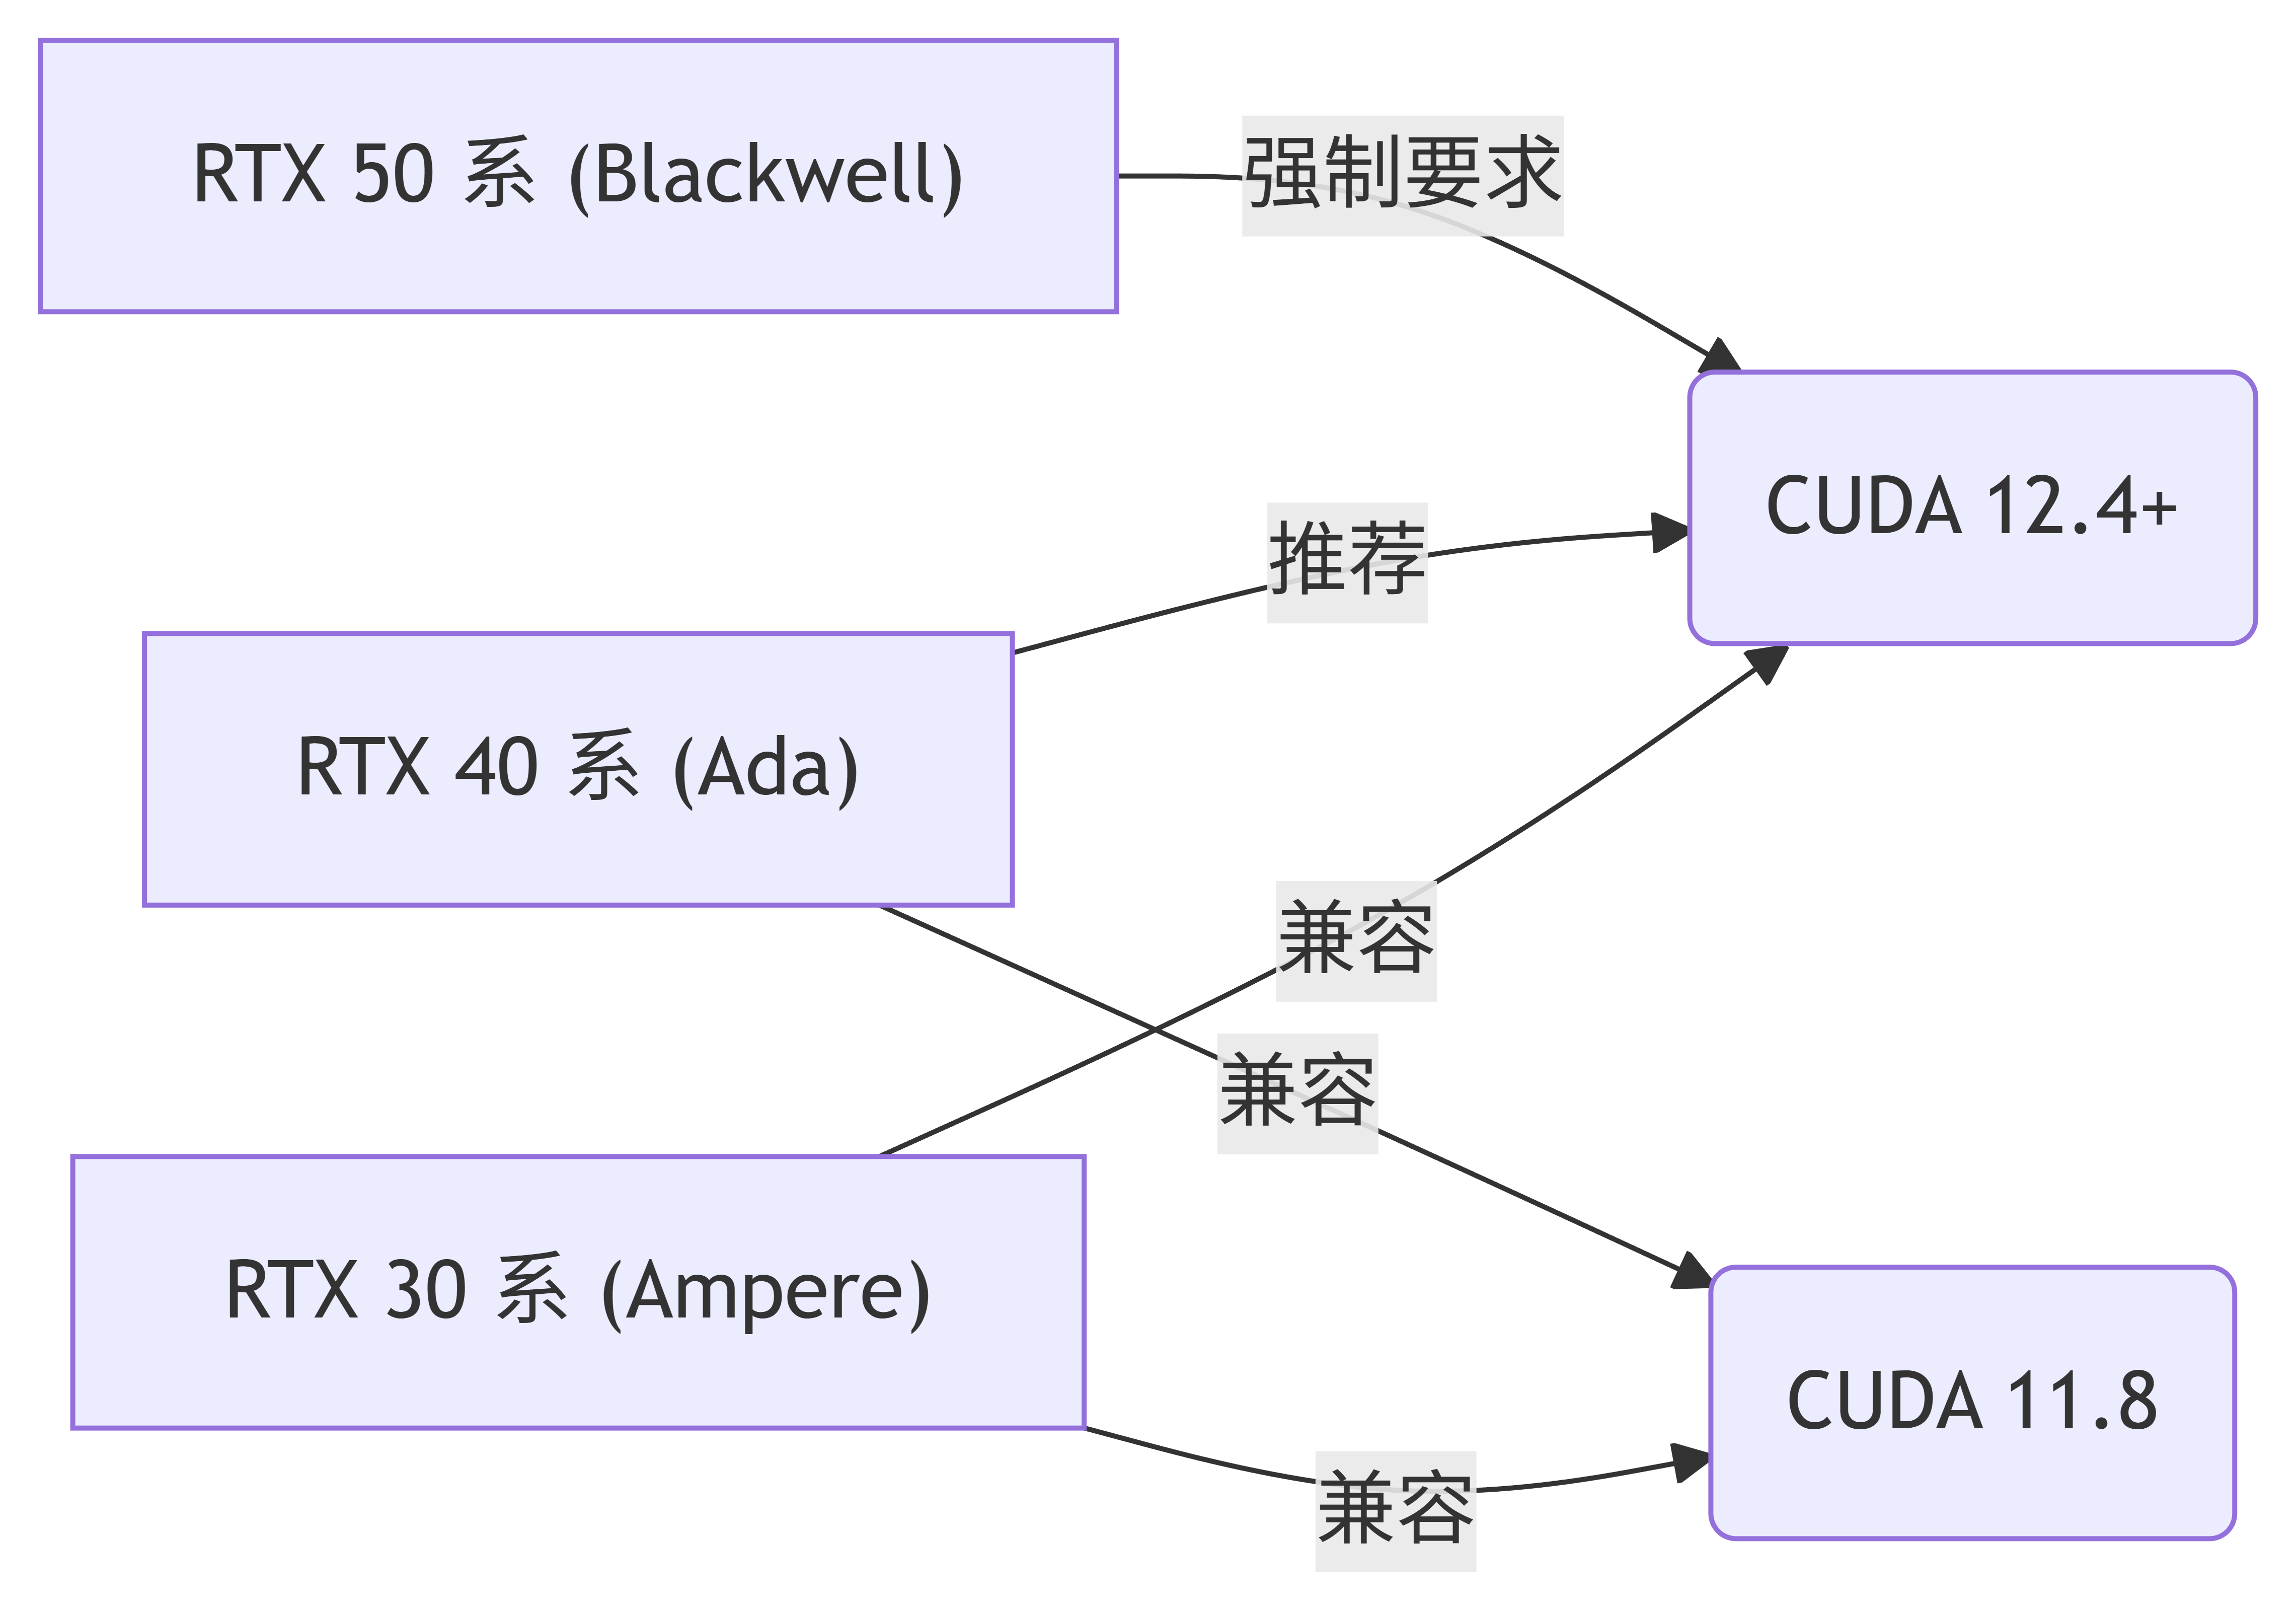

PyTorch 是目前兼容性最好的框架，只要 CUDA 驱动版本 足高，通常都能向下兼容。对于使用最新硬件（如 RTX 50 系）的用户，请务必使用 2.4 或更高版本。

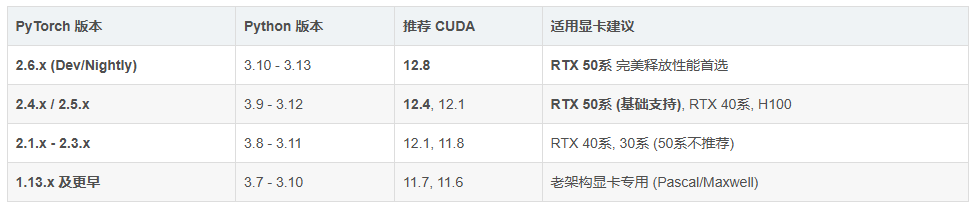

如果你使用的是 Blackwell 架构 (RTX 50系) 或 Ada 架构 (RTX 40系)，建议优先使用 CUDA 12.x 的 PyTorch 包.



显卡架构决定了你的算力上限 (Compute Capability) 和 CUDA 版本的下限。**新卡不能装太旧的 CUDA，老卡通常可以使用新 CUDA**。

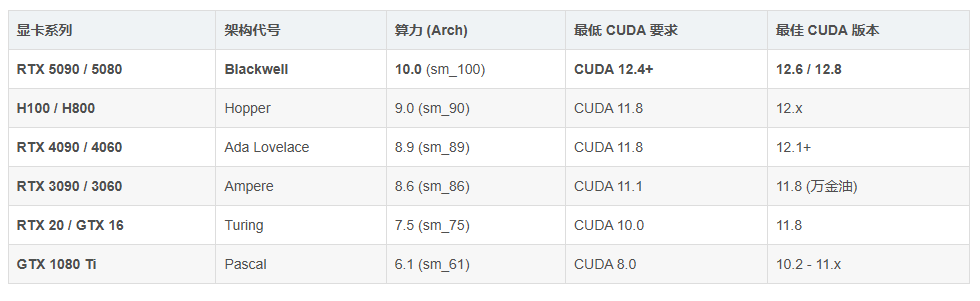

可以选择一个靠近你的显卡版本,我使用下来没有出错过.这样我们就可以选择出来我们配置下,比较合适的CUDA,Pytorch与Python的对应版本.

最后给大家总结几套不想动脑子的“黄金配置”，请根据自己的硬件对号入座：

1. 前沿性能组 (RTX 50/40系)：

    - 搭配：Python 3.11 + PyTorch 2.5/2.6 + CUDA 12.4+
    - 理由：发挥新架构 (FP8 等) 极致性能，必须拥抱 CUDA 12。

2. 主流稳定组 (RTX 30/40系)：

    - 搭配：Python 3.10 + PyTorch 2.3/2.4 + CUDA 12.1
    - 理由：市面上绝大多数开源项目都能跑，兼容性最佳。

3. 经典兼容组 (RTX 20/30系)：

    - 搭配：Python 3.9/3.10 + PyTorch 2.0 + CUDA 11.8
    - 理由：CUDA 11.8 是过去几年的统一度量衡，极其稳定。

4. 古董收藏组 (GTX 10系)：

    - 搭配：Python 3.8 + PyTorch 1.12 + CUDA 11.3
    - 理由：老卡就别追新了，能跑起来就是胜利。